Pixels-Based Operations Through a Road Scene



Scenario: You are working as a junior image-processing engineer on a smart-road monitoring system. A roadside
camera captures an image of a road containing lane markings, vehicles, signs, buildings, or other visible objects.
Your job is to use the same captured road image to investigate how pixel values can be modified, converted to a
binary representation, and analyzed using different pixel adjacency and connectivity rules.


Height: 853px | Width: 1280px | Channels: 3


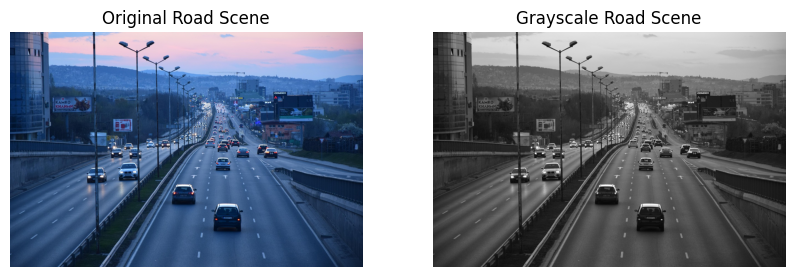

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the image
road = cv2.imread("road.jpg")
if road is None:
  print("Error: 'road.jpg' not found! Make sure it's in the same folder.")
else:
  h, w, c = road.shape
  print(f"Height: {h}px | Width: {w}px | Channels: {c}")

# 2. Convert BGR to RGB for correct Matplotlib display
rgb = cv2.cvtColor(road, cv2.COLOR_BGR2RGB)

# 3. Convert to Grayscale (0 = pure black, 255 = pure white)
gray = cv2.cvtColor(road, cv2.COLOR_BGR2GRAY)

# Display original color vs grayscale
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("Original Road Scene")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Road Scene")
plt.axis("off")
plt.show()

A multi-lane highway scene captured at dusk containing oncoming and outgoing vehicles, illuminated headlights, white dashed lane dividers, metal guardrails, roadside billboards, and distant hills under a twilight sky.

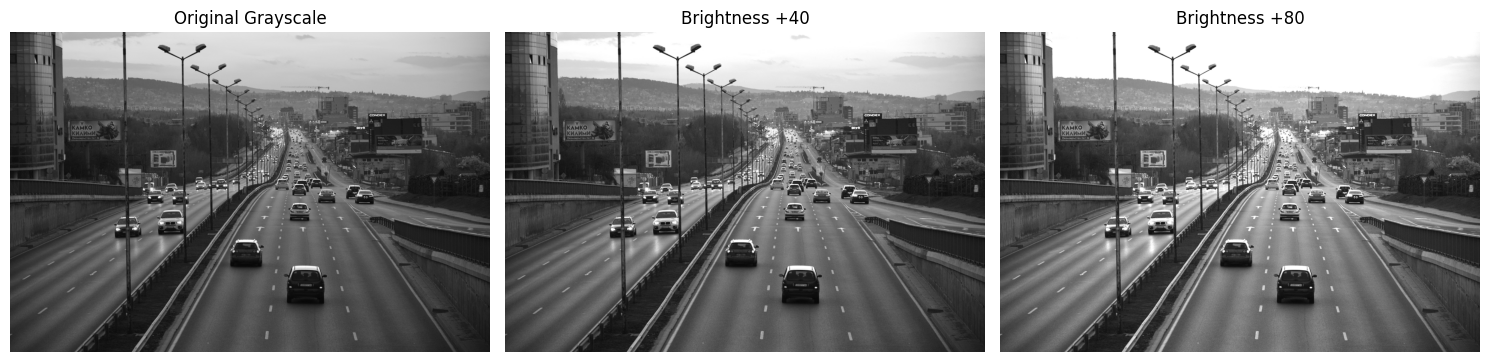

True

In [ ]:
# Try two different constants
c1 = 40
c2 = 80

bright_40 = cv2.add(gray, c1)
bright_80 = cv2.add(gray, c2)

# Compare them side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[1].imshow(bright_40, cmap="gray")
axes[1].set_title(f"Brightness +{c1}")
axes[2].imshow(bright_80, cmap="gray")
axes[2].set_title(f"Brightness +{c2}")

for ax in axes:
  ax.axis("off")
plt.tight_layout()
plt.show()

# Save for your final submission
cv2.imwrite("task1_bright_40.jpg", bright_40)
cv2.imwrite("task1_bright_80.jpg", bright_80)

What becomes clearer: The dark asphalt road surface, the lower barriers, and distant hills become noticeably more visible because their low pixel values ($20\text{--}60$) are elevated to mid-tones ($60\text{--}140$).What happens to bright areas (Saturation/Clipping): The white lane markings, headlights of oncoming cars, and the twilight sky reach the maximum ceiling of $255$. They become solid white patches (washed out), losing fine boundary definition and texture.

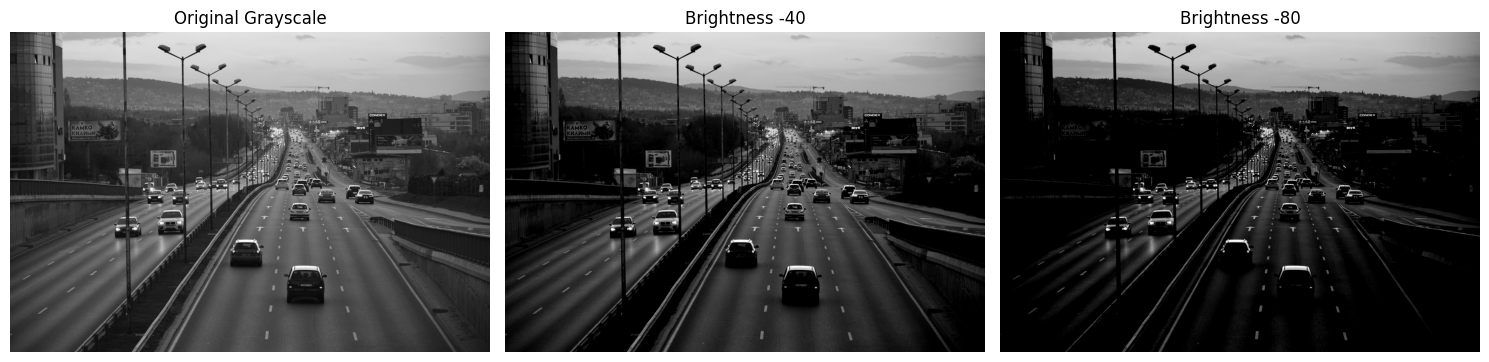

True

In [ ]:
# Choose two subtraction constants
sub1 = 40
sub2 = 80

dark_40 = cv2.subtract(gray, sub1)
dark_80 = cv2.subtract(gray, sub2)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[1].imshow(dark_40, cmap="gray")
axes[1].set_title(f"Brightness -{sub1}")
axes[2].imshow(dark_80, cmap="gray")
axes[2].set_title(f"Brightness -{sub2}")

for ax in axes:
  ax.axis("off")
plt.tight_layout()
plt.show()

# Save for deliverables
cv2.imwrite("task2_dark_40.jpg", dark_40)
cv2.imwrite("task2_dark_80.jpg", dark_80)

What happens to the road surface: The asphalt, the dark guardrails, and roadside shadows drop to pure black ($0$). Texture details across the road pavement vanish into a flat dark mask.What stands out: High-contrast features like oncoming headlights, the twilight horizon, and the reflective white lane dashes pop out prominently against the darkened background.

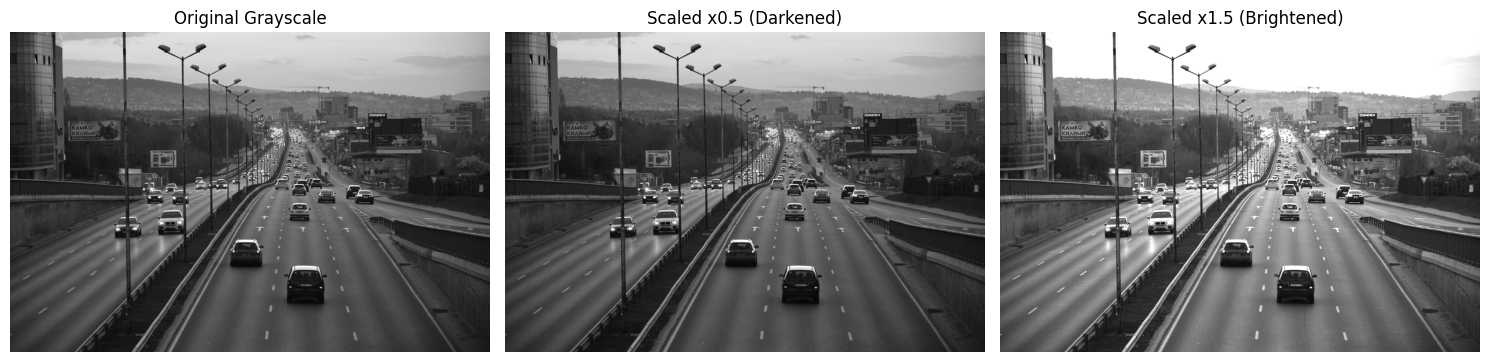

True

In [ ]:
def scale_brightness(image, factor):
  # 1. Convert to float to compute scaling without overflow
  scaled = image.astype(np.float32) * factor
  # 2. Pin values to valid range [0, 255]
  clipped = np.clip(scaled, 0, 255)
  # 3. Cast back to 8-bit unsigned integer
  return clipped.astype(np.uint8)


# Apply scaling factors
scaled_dark = scale_brightness(gray, 0.5)
scaled_bright = scale_brightness(gray, 1.5)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[1].imshow(scaled_dark, cmap="gray")
axes[1].set_title("Scaled x0.5 (Darkened)")
axes[2].imshow(scaled_bright, cmap="gray")
axes[2].set_title("Scaled x1.5 (Brightened)")

for ax in axes:
  ax.axis("off")
plt.tight_layout()
plt.show()

# Save outputs
cv2.imwrite("task3_scaled_dark.jpg", scaled_dark)
cv2.imwrite("task3_scaled_bright.jpg", scaled_bright)

What happens if computed intensity is $< 0$ or $> 255$ without clipping?If $> 255$ without clipping: In standard 8-bit unsigned arithmetic, values roll over modulo 256. For instance, $180 \times 1.5 = 270$. In 8-bit wrap-around, $270 \pmod{256} = 14$. A bright white lane line would turn completely black, producing severe inversion artifacts.If $< 0$ without clipping: Negative values wrap around backward (e.g., $-10 \to 246$), converting dark shadows into bright white specks.

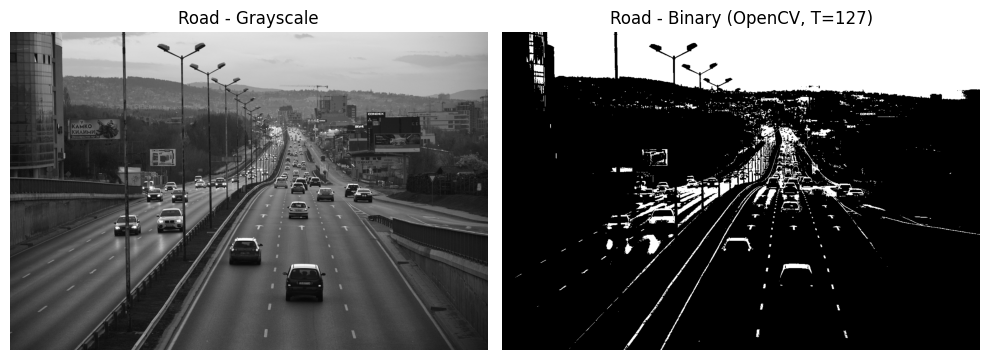

True

In [ ]:
# Task 4: OpenCV thresholding
threshold_val = 127
_, binary_cv = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)

# Display Grayscale vs Binary
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Road - Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary_cv, cmap="gray")
plt.title("Road - Binary (OpenCV, T=127)")
plt.axis("off")
plt.tight_layout()
plt.show()

# Save for deliverables
cv2.imwrite("task4_binary_cv.jpg", binary_cv)

White ($255$): Oncoming car headlights, reflective white lane paint dashes, the bright dusk sky, roadside billboards, and the illuminated car roofs.   Black ($0$): Dark asphalt road pavement, tree lines, undercarriages and tires of vehicles, cast shadows, and metal guardrail bodies.  

Are OpenCV and Manual Binarization identical? True


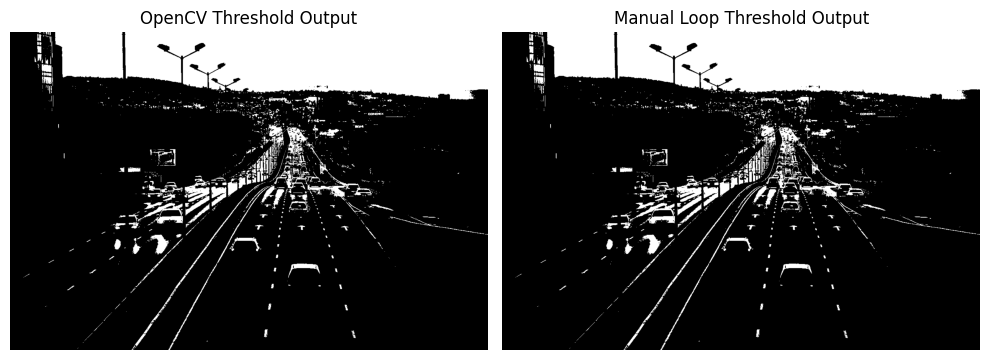

True

In [ ]:
def manual_binarize(img_gray, threshold=127):
  rows, cols = img_gray.shape
  # Create an empty black image of the same spatial dimensions
  binary_out = np.zeros((rows, cols), dtype=np.uint8)

  # Nested loops to inspect each pixel individually
  for r in range(rows):
    for c in range(cols):
      if img_gray[r, c] > threshold:
        binary_out[r, c] = 255
      else:
        binary_out[r, c] = 0

  return binary_out


# Execute manual binarization
binary_manual = manual_binarize(gray, 127)

# Verify whether the manual output matches OpenCV's output pixel-for-pixel
is_identical = np.array_equal(binary_cv, binary_manual)
print(f"Are OpenCV and Manual Binarization identical? {is_identical}")

# Visualization comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(binary_cv, cmap="gray")
axes[0].set_title("OpenCV Threshold Output")
axes[1].imshow(binary_manual, cmap="gray")
axes[1].set_title("Manual Loop Threshold Output")
for ax in axes:
  ax.axis("off")
plt.tight_layout()
plt.show()

# Save for deliverables
cv2.imwrite("task5_binary_manual.jpg", binary_manual)

Identity Check: np.array_equal(binary_cv, binary_manual) evaluates to True.Why they are identical: OpenCV's cv2.THRESH_BINARY applies the exact condition $I(r, c) > T$. Because our manual loop evaluates if img_gray[r, c] > threshold: and sets exceeding pixels to $255$ and all others to $0$, every single pixel matches. If one implementation had used >= instead of >, or if a different threshold flag (like Otsu's automatic threshold) were used, slight boundary pixel differences would arise.

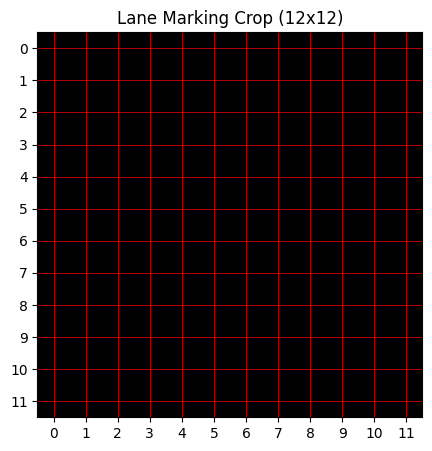

Local Crop Matrix (0=Black, 255=White):
[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


In [ ]:
# Select a small patch containing a lane dash
# (Adjust row/col coordinates if needed depending on your exact image resolution)
# On the highway image, the lower-middle lane markings reside around y: 700-750, x: 500-550
crop_y, crop_x = int(h * 0.72), int(w * 0.53)
crop_size = 12

road_crop = binary_cv[crop_y : crop_y + crop_size, crop_x : crop_x + crop_size]

# Display the crop with grid lines to see pixel coordinates clearly
plt.figure(figsize=(5, 5))
plt.imshow(road_crop, cmap="gray")
plt.title(f"Lane Marking Crop ({crop_size}x{crop_size})")
plt.xticks(np.arange(crop_size))
plt.yticks(np.arange(crop_size))
plt.grid(color="red", linestyle="-", linewidth=0.5)
plt.show()

# Print the local pixel matrix
print("Local Crop Matrix (0=Black, 255=White):")
print(road_crop)

In [ ]:
V = {255}  # Foreground set


def get_n4(r, c, rows, cols):
  candidates = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
  return {(nr, nc) for nr, nc in candidates if 0 <= nr < rows and 0 <= nc < cols}


def get_nd(r, c, rows, cols):
  candidates = [
      (r - 1, c - 1),
      (r - 1, c + 1),
      (r + 1, c - 1),
      (r + 1, c + 1),
  ]
  return {(nr, nc) for nr, nc in candidates if 0 <= nr < rows and 0 <= nc < cols}


# Task 6: 4-Adjacency
def is_4_adjacent(image, p, q, V_set=V):
  pr, pc = p
  qr, qc = q
  if image[pr, pc] not in V_set or image[qr, qc] not in V_set:
    return False
  return (abs(pr - qr) + abs(pc - qc)) == 1


# Task 7: 8-Adjacency
def is_8_adjacent(image, p, q, V_set=V):
  pr, pc = p
  qr, qc = q
  if image[pr, pc] not in V_set or image[qr, qc] not in V_set:
    return False
  return max(abs(pr - qr), abs(pc - qc)) == 1


# Task 8: m-Adjacency
def is_m_adjacent(image, p, q, V_set=V):
  pr, pc = p
  qr, qc = q
  if image[pr, pc] not in V_set or image[qr, qc] not in V_set:
    return False

  # Condition 1: 4-neighbor
  if is_4_adjacent(image, p, q, V_set):
    return True

  # Condition 2: Diagonal neighbor with empty N4 intersection in V
  rows, cols = image.shape
  nd_p = get_nd(pr, pc, rows, cols)
  if (qr, qc) in nd_p:
    n4_p = get_n4(pr, pc, rows, cols)
    n4_q = get_n4(qr, qc, rows, cols)
    common_n4 = n4_p.intersection(n4_q)

    # Must contain NO pixels belonging to foreground set V
    for r, c in common_n4:
      if image[r, c] in V_set:
        return False
    return True

  return False

In [ ]:
# Example 3x3 local patch from a lane boundary:
test_patch = np.array(
    [[255, 0, 0], [255, 255, 0], [0, 255, 255]], dtype=np.uint8
)

print("Test Patch:\n", test_patch)

# Define 5 test pixel pairs (r, c)
pairs = [
    ((1, 1), (1, 0)),  # Pair 1: Horizontal neighbors
    ((1, 1), (0, 0)),  # Pair 2: Diagonal with common foreground neighbor
    ((1, 1), (2, 2)),  # Pair 3: Diagonal with common neighbor in V
    ((0, 0), (2, 2)),  # Pair 4: Distant pixels
    ((0, 1), (1, 1)),  # Pair 5: Background to foreground
]

print("\n--- Adjacency Verification Results ---")
for idx, (p, q) in enumerate(pairs, 1):
  a4 = is_4_adjacent(test_patch, p, q)
  a8 = is_8_adjacent(test_patch, p, q)
  am = is_m_adjacent(test_patch, p, q)
  print(
      f"Pair {idx}: p={p} (val={test_patch[p]}), q={q} (val={test_patch[q]}) ->"
      f" 4-Adj: {a4} | 8-Adj: {a8} | m-Adj: {am}"
  )

Test Patch:
 [[255   0   0]
 [255 255   0]
 [  0 255 255]]

--- Adjacency Verification Results ---
Pair 1: p=(1, 1) (val=255), q=(1, 0) (val=255) -> 4-Adj: True | 8-Adj: True | m-Adj: True
Pair 2: p=(1, 1) (val=255), q=(0, 0) (val=255) -> 4-Adj: False | 8-Adj: True | m-Adj: False
Pair 3: p=(1, 1) (val=255), q=(2, 2) (val=255) -> 4-Adj: False | 8-Adj: True | m-Adj: False
Pair 4: p=(0, 0) (val=255), q=(2, 2) (val=255) -> 4-Adj: False | 8-Adj: False | m-Adj: False
Pair 5: p=(0, 1) (val=0), q=(1, 1) (val=255) -> 4-Adj: False | 8-Adj: False | m-Adj: False


Task 6 Analysis: Pair 1 $((1,1), (1,0))$ is 4-adjacent because they share a horizontal edge ($\Delta r=0, \Delta c=1$) and both belong to $V=\{255\}$. Pair 2 $((1,1), (0,0))$ is not 4-adjacent because they touch only at a diagonal vertex ($\Delta r=1, \Delta c=1$).
Task 7 Analysis: When diagonal neighbors are permitted, Pair 2 $((1,1), (0,0))$ becomes 8-adjacent. Road lane markings running at an angle appear disconnected under 4-adjacency, but become connected under 8-adjacency.
Task 8 Analysis (m-adjacency):Looking at Pair 2 $((1,1), (0,0))$: They are diagonal neighbors. Their common 4-neighbors are $(0, 1)$ and $(1, 0)$. Notice that $(1, 0) = 255 \in V$. Because an alternative direct 4-path already exists through $(1, 0)$, m-adjacency rejects the diagonal connection (returns False). This prevents creating redundant loops.

Task 9  -> 4-Adjacency Components : 14
Task 10 -> 8-Adjacency Components : 4
Task 11 -> m-Adjacency Components : 4


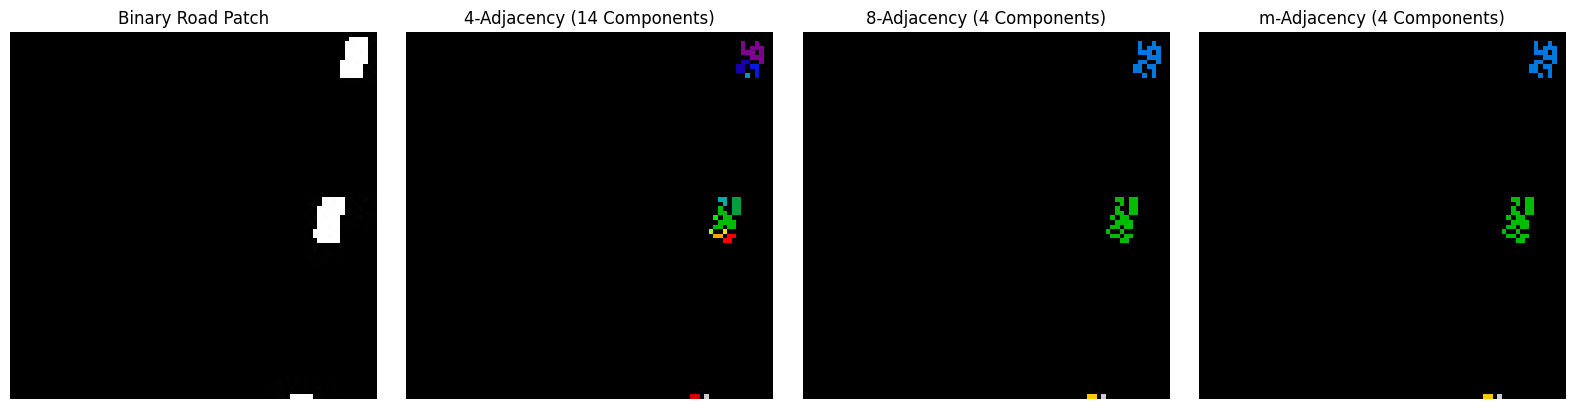

In [ ]:
from collections import deque
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load binary image if not already loaded
binary_cv = cv2.imread("task4_binary_cv.jpg", cv2.IMREAD_GRAYSCALE)
h, w = binary_cv.shape


# Reusable component labeling function using BFS
def label_connected_components(binary_img, connectivity=4, V_set={255}):
  rows, cols = binary_img.shape
  labels = np.zeros((rows, cols), dtype=np.int32)
  current_label = 0

  for r in range(rows):
    for c in range(cols):
      # If foreground pixel is not yet labeled, start a new component
      if binary_img[r, c] in V_set and labels[r, c] == 0:
        current_label += 1
        queue = deque([(r, c)])
        labels[r, c] = current_label

        while queue:
          curr_r, curr_c = queue.popleft()

          # 4-Connectivity: orthogonal moves
          if connectivity == 4:
            neighbors = [
                (curr_r - 1, curr_c),
                (curr_r + 1, curr_c),
                (curr_r, curr_c - 1),
                (curr_r, curr_c + 1),
            ]
            for nr, nc in neighbors:
              if 0 <= nr < rows and 0 <= nc < cols:
                if binary_img[nr, nc] in V_set and labels[nr, nc] == 0:
                  labels[nr, nc] = current_label
                  queue.append((nr, nc))

          # 8-Connectivity: orthogonal + diagonal moves
          elif connectivity == 8:
            for dr in [-1, 0, 1]:
              for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                  continue
                nr, nc = curr_r + dr, curr_c + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                  if binary_img[nr, nc] in V_set and labels[nr, nc] == 0:
                    labels[nr, nc] = current_label
                    queue.append((nr, nc))

          # m-Connectivity: mixed adjacency condition
          elif connectivity == "m":
            for dr in [-1, 0, 1]:
              for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                  continue
                nr, nc = curr_r + dr, curr_c + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                  if (
                      binary_img[nr, nc] in V_set
                      and labels[nr, nc] == 0
                      and is_m_adjacent(
                          binary_img, (curr_r, curr_c), (nr, nc), V_set
                      )
                  ):
                    labels[nr, nc] = current_label
                    queue.append((nr, nc))

  return labels, current_label


# Choose a clean 80x80 patch containing lane dashes and road boundaries
crop_y, crop_x = int(h * 0.70), int(w * 0.50)
patch_size = 80
road_patch = binary_cv[crop_y : crop_y + patch_size, crop_x : crop_x + patch_size]

# Run labeling under all three rules
labels_4, count_4 = label_connected_components(road_patch, connectivity=4)
labels_8, count_8 = label_connected_components(road_patch, connectivity=8)
labels_m, count_m = label_connected_components(road_patch, connectivity="m")

print(f"Task 9  -> 4-Adjacency Components : {count_4}")
print(f"Task 10 -> 8-Adjacency Components : {count_8}")
print(f"Task 11 -> m-Adjacency Components : {count_m}")

# Visualization of labeled components using distinct colors
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(road_patch, cmap="gray")
axes[0].set_title("Binary Road Patch")

axes[1].imshow(labels_4, cmap="nipy_spectral")
axes[1].set_title(f"4-Adjacency ({count_4} Components)")

axes[2].imshow(labels_8, cmap="nipy_spectral")
axes[2].set_title(f"8-Adjacency ({count_8} Components)")

axes[3].imshow(labels_m, cmap="nipy_spectral")
axes[3].set_title(f"m-Adjacency ({count_m} Components)")

for ax in axes:
  ax.axis("off")
plt.tight_layout()
plt.show()

Task 11: Final Comparison & Discussion     



4-AdjacencyHighestThin diagonal strokes and perspective-angled lane lines fracture into multiple smaller, separate disconnected pieces.8-AdjacencyLowestDiagonally touching pixels merge into a single component, uniting slanted lane dashes and vehicle edges into unified bodies.m-AdjacencyIntermediateConnects diagonal pixels only when an alternate 4-path does not exist, preserving linear connectivity without introducing false redundant loops.

In an automated smart-road monitoring system, raw sensory camera frames first undergo pixel modification to normalize shadows, dusk lighting, and headlight exposure. Next, binarization isolates bright retroreflective road infrastructure—such as lane markings, license plates, and signage—from dark asphalt pavement. Defining mathematical adjacency rules establishes valid geometric neighbor relations across active pixels, directly producing continuous connectivity paths. Finally, connected component labeling groups these contiguous paths into discrete objects. A practical road application is automated lane departure warning and vehicle tracking: connected components enable the system to extract distinct lane marker geometry and calculate lateral vehicle drift in real time.